# 모터 진동 시계열 분석 — 정상 / 베어링 내륜 결함 / 회전체 불평형

**데이터**: Multi-domain vibration dataset (Mendeley Data, DOI 10.17632/2cygy6y4rk.1) subset 3
**대상**: 16 kHz, 1200 rpm으로 측정한 80초 진동 신호 3개 (설비 1대당 1,280,000 포인트)

| 설비 | 파일 라벨 | 상태 |
| --- | --- | --- |
| `MOTOR_001` | `H_H` | 정상 회전체 + 정상 베어링 |
| `MOTOR_002` | `H_IR` | 정상 회전체 + 베어링 **내륜 결함** |
| `MOTOR_003` | `U1_H` | **불평형** 회전체 + 정상 베어링 |

## 분석 질문

1. **진동의 크기(RMS)만으로 세 설비의 상태를 구분할 수 있는가?**
2. **크기 말고 "파형의 모양"에서 드러나는 차이가 있는가?** (충격성 = Crest / Kurtosis, 그리고 변화율)
3. **이 시계열에 트렌드·주기성(계절성)·노이즈는 각각 어떻게 나타나는가?** 주파수 영역에서 결함의 단서를 찾을 수 있는가?
4. (응용) 위 지표로 **실시간 알람 임계값**을 잡는다면 어디에 두어야 하는가?

> 이 노트북은 `관찰`(그래프에서 그대로 읽히는 사실)과 `해석`(그 사실에 대한 가설)을 각 절 끝에서 나누어 적는다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.stats import kurtosis

DATA_DIR = Path("../data/jsonl")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

FS = 16000          # 샘플링 레이트 (Hz)
FRAME = 8000        # 특징 계산 구간 0.5초
HOP = 4000          # 0.25초마다 한 점 -> 80초에서 319개 포인트
ROT_HZ = 1200 / 60  # 회전 주파수 20 Hz

LABELS = {
    "MOTOR_001": "MOTOR_001 정상 (H_H)",
    "MOTOR_002": "MOTOR_002 베어링 내륜 결함 (H_IR)",
    "MOTOR_003": "MOTOR_003 회전체 불평형 (U1_H)",
}
COLORS = {"MOTOR_001": "#2e7d32", "MOTOR_002": "#c62828", "MOTOR_003": "#1565c0"}

installed = {f.name for f in font_manager.fontManager.ttflist}
for candidate in ("Malgun Gothic", "NanumGothic", "AppleGothic"):
    if candidate in installed:
        plt.rcParams["font.family"] = candidate
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

## 1. 데이터 불러오기

JSONL 파일 한 줄은 2초짜리 window(32,000 샘플)이고, window는 1초(16,000 샘플)씩 겹쳐 있다.
따라서 각 window의 앞 16,000 샘플만 이어 붙이면 원래의 연속 신호 80초를 그대로 복원할 수 있다.
겹치는 구간이 실제로 일치하는지 먼저 확인한 뒤 복원한다.

In [2]:
def load_signal(path):
    """JSONL window를 읽어 연속 신호 한 개로 복원한다."""
    windows, meta = [], None
    with path.open(encoding="utf-8") as fp:
        for line in fp:
            row = json.loads(line)
            if meta is None:
                meta = {k: row[k] for k in ("equipmentId", "samplingRate", "rpm", "windowSize")}
            windows.append(np.asarray(row["values"], dtype=float))

    stacked = np.stack(windows)
    overlap_gap = max(
        np.abs(stacked[i, HOP * 4:] - stacked[i + 1, :HOP * 4]).max()
        for i in range(len(stacked) - 1)
    )
    signal = np.concatenate([w[:HOP * 4] for w in stacked[:-1]] + [stacked[-1]])
    return signal, meta, len(stacked), overlap_gap


signals, summary = {}, []
for path in sorted(DATA_DIR.glob("*.jsonl")):
    signal, meta, n_windows, overlap_gap = load_signal(path)
    signals[meta["equipmentId"]] = signal
    summary.append({
        "설비": meta["equipmentId"],
        "window 수": n_windows,
        "겹침 구간 최대 오차": overlap_gap,
        "복원 샘플 수": len(signal),
        "측정 길이(초)": len(signal) / FS,
        "rpm": meta["rpm"],
    })

pd.DataFrame(summary).set_index("설비")

,window 수,겹침 구간 최대 오차,복원 샘플 수,측정 길이(초),rpm
설비,,,,,
MOTOR_001,79,0.0,1280000,80.0,1200
MOTOR_002,79,0.0,1280000,80.0,1200
MOTOR_003,79,0.0,1280000,80.0,1200


**관찰** — 겹침 구간의 최대 오차가 0이므로 window는 손실 없이 이어진다. 설비마다 1,280,000 샘플(80초)이 복원되었고, 과제 기준(100 포인트 이상)을 크게 넘는다.

## 2. 데이터 품질 점검 — 결측치와 이상치

- **결측치 기준**: `NaN`, `inf`, 그리고 window 누락(80초 × 16 kHz = 1,280,000 샘플에서 모자란 샘플).
- **이상치 기준**: 설비별 평균에서 ±6σ를 벗어난 샘플. 단, **이 분석에서는 제거하지 않는다.** 진동 신호에서 큰 튐은 측정 오류가 아니라 베어링 결함이 만드는 충격 그 자체이고, 그것을 지우면 찾으려는 신호가 사라지기 때문이다. 대신 몇 개인지 세어 두고 해석에 사용한다.

In [3]:
quality = []
for eq, signal in signals.items():
    sigma = signal.std()
    outlier = np.abs(signal - signal.mean()) > 6 * sigma
    quality.append({
        "설비": eq,
        "NaN": int(np.isnan(signal).sum()),
        "inf": int(np.isinf(signal).sum()),
        "누락 샘플": 1_280_000 - len(signal),
        "평균": signal.mean(),
        "표준편차": sigma,
        "최소": signal.min(),
        "최대": signal.max(),
        "±6σ 밖 샘플": int(outlier.sum()),
        "±6σ 밖 비율(%)": outlier.mean() * 100,
    })

pd.DataFrame(quality).set_index("설비").round(6)

,NaN,inf,누락 샘플,평균,표준편차,최소,최대,±6σ 밖 샘플,±6σ 밖 비율(%)
설비,,,,,,,,,
MOTOR_001,0,0,0,-0.000002,0.134558,-0.902331,0.908290,11,0.000859
MOTOR_002,0,0,0,-0.000002,0.350608,-5.242078,6.565904,1417,0.110703
MOTOR_003,0,0,0,0.000012,0.142402,-0.996900,0.991471,4,0.000312


**관찰** — 결측치(NaN/inf/누락)는 세 설비 모두 0이다. ±6σ를 벗어난 샘플은 `MOTOR_001` 11개, `MOTOR_003` 4개인 반면 `MOTOR_002`는 1,417개(0.11%)로 100배 이상 많다.

**해석(가설)** — 측정 장비와 측정 길이가 같고 결측도 없는데 `MOTOR_002`만 큰 튐이 잦다면, 이는 센서 오류가 아니라 기계적 충격일 가능성이 높다. 아래 절에서 지표로 확인한다.

## 3. 특징 시계열 만들기

원신호 1,280,000 포인트를 그대로 보면 아무 패턴도 보이지 않는다.
**0.5초 구간(FRAME)을 0.25초씩(HOP) 밀면서** 구간마다 대표값을 계산해, 설비당 319개 포인트의 시계열 4종을 만든다.

| 지표 | 의미 |
| --- | --- |
| RMS | 진동 에너지의 크기 (얼마나 크게 떨리는가) |
| Peak-to-Peak | 구간 내 최댓값 - 최솟값 |
| Crest factor | 최댓값 / RMS (평균 대비 얼마나 뾰족한가) |
| Kurtosis | 분포의 뾰족함. 정상 진동은 가우시안에 가까워 약 3, 충격이 섞이면 커진다 |

In [4]:
def frame_features(signal):
    n_frames = (len(signal) - FRAME) // HOP + 1
    frames = np.stack([signal[i * HOP:i * HOP + FRAME] for i in range(n_frames)])
    rms = np.sqrt((frames ** 2).mean(axis=1))
    return pd.DataFrame({
        "t": np.arange(n_frames) * HOP / FS,
        "rms": rms,
        "p2p": frames.max(axis=1) - frames.min(axis=1),
        "crest": np.abs(frames).max(axis=1) / rms,
        "kurtosis": kurtosis(frames, axis=1, fisher=False),
    })


features = pd.concat(
    [frame_features(signal).assign(equipment=eq) for eq, signal in signals.items()],
    ignore_index=True,
)
features.to_csv("features_window.csv", index=False)

print(f"설비당 포인트 수: {len(features) // len(signals)}   총 {len(features)} 포인트")
features.groupby("equipment")[["rms", "p2p", "crest", "kurtosis"]].agg(["mean", "std", "max"]).round(3)

설비당 포인트 수: 319   총 957 포인트


rms                  p2p                 crest                 \
            mean    std    max   mean    std     max   mean    std     max   
equipment                                                                    
MOTOR_001  0.135  0.003  0.147  1.227  0.127   1.811  4.928  0.559   6.632   
MOTOR_002  0.350  0.021  0.418  5.867  1.649  11.786  9.011  2.420  16.263   
MOTOR_003  0.142  0.004  0.155  1.251  0.114   1.619  4.658  0.505   6.654   

          kurtosis                 
              mean    std     max  
equipment                          
MOTOR_001    3.490  0.218   4.331  
MOTOR_002    9.905  4.096  31.441  
MOTOR_003    3.456  0.208   4.257

## 4. 시각화 ① 원신호 파형 — 같은 0.2초를 비교하면

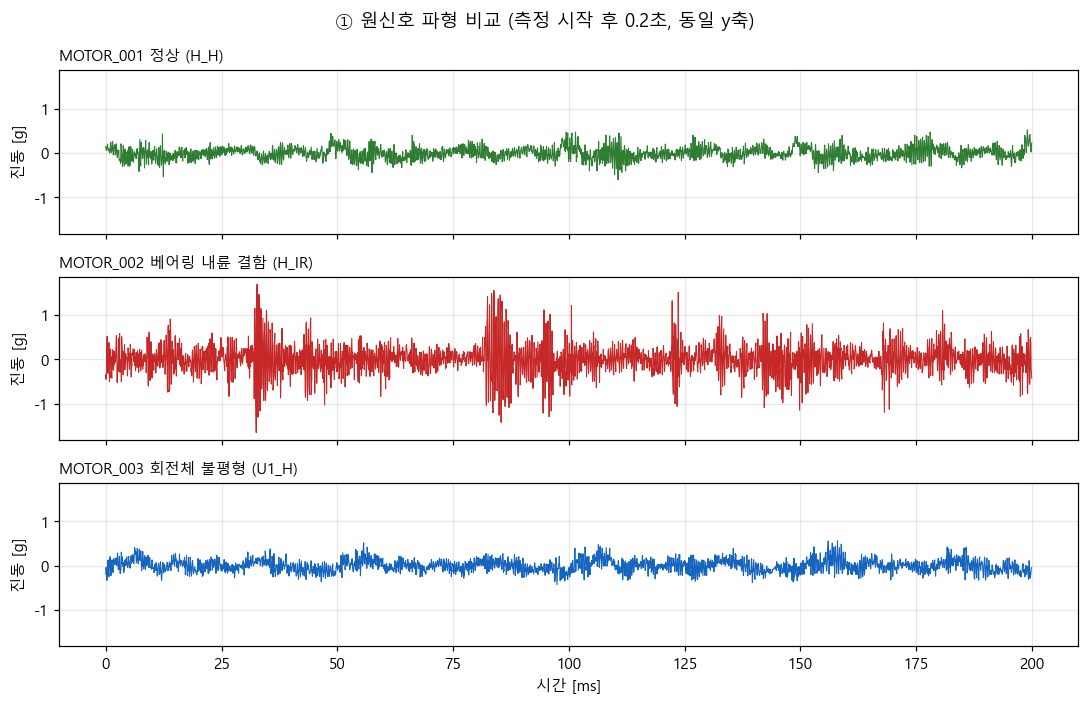

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True, sharey=True)
span = slice(0, int(0.2 * FS))
t_ms = np.arange(span.stop) / FS * 1000

for ax, (eq, signal) in zip(axes, signals.items()):
    ax.plot(t_ms, signal[span], color=COLORS[eq], linewidth=0.7)
    ax.set_title(LABELS[eq], fontsize=10, loc="left")
    ax.set_ylabel("진동 [g]")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("시간 [ms]")
fig.suptitle("① 원신호 파형 비교 (측정 시작 후 0.2초, 동일 y축)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_waveform.png", bbox_inches="tight")
plt.show()

**관찰** — 동일한 y축에서 `MOTOR_001`과 `MOTOR_003`의 파형은 거의 같은 폭 안에서 움직인다. `MOTOR_002`만 진폭이 수 배 크고, 뾰족한 스파이크가 반복된다.

**해석(가설)** — `MOTOR_002`의 반복 스파이크는 결함 지점을 구름 요소가 지날 때마다 발생하는 충격으로 보인다. 반면 불평형(`MOTOR_003`)은 파형 크기로는 정상과 구별되지 않으므로, 시간 영역 크기 지표만으로는 놓칠 수 있다.

## 5. 시각화 ② RMS 시계열과 이동평균 — 트렌드 / 노이즈 분리

시계열을 **트렌드(장기 추세) + 주기성 + 노이즈(단기 변동)** 로 나누어 본다.
이동평균은 짧은 변동을 깎아내 장기 추세만 남기는 가장 단순한 방법이라 먼저 적용한다.
여기서는 **4초 이동평균**(0.25초 간격 16 포인트)을 사용했다.

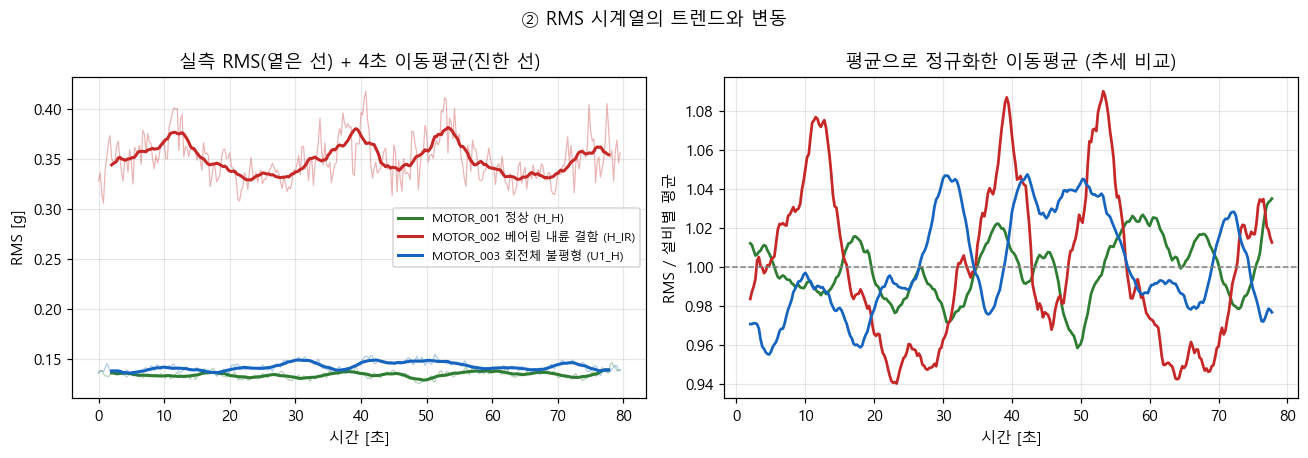

,RMS 평균,RMS 표준편차,변동계수 CV,80초 추세 변화율(%)
설비,,,,
MOTOR_001,0.1345,0.0033,0.0249,1.6452
MOTOR_002,0.3500,0.0213,0.0609,-1.0730
MOTOR_003,0.1423,0.0045,0.0315,2.6719


In [6]:
window_ma = 16  # 0.25초 간격 × 16 = 4초

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
trend_rows = []

for eq in signals:
    part = features[features.equipment == eq]
    ma = part.rms.rolling(window_ma, center=True).mean()
    axes[0].plot(part.t, part.rms, color=COLORS[eq], alpha=0.35, linewidth=0.8)
    axes[0].plot(part.t, ma, color=COLORS[eq], linewidth=2, label=LABELS[eq])

    slope, _ = np.polyfit(part.t, part.rms, 1)
    trend_rows.append({
        "설비": eq,
        "RMS 평균": part.rms.mean(),
        "RMS 표준편차": part.rms.std(),
        "변동계수 CV": part.rms.std() / part.rms.mean(),
        "80초 추세 변화율(%)": slope * 80 / part.rms.mean() * 100,
    })

    normalized = part.rms / part.rms.mean()
    axes[1].plot(part.t, normalized.rolling(window_ma, center=True).mean(),
                 color=COLORS[eq], linewidth=1.8, label=LABELS[eq])

axes[0].set(xlabel="시간 [초]", ylabel="RMS [g]", title="실측 RMS(옅은 선) + 4초 이동평균(진한 선)")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[1].set(xlabel="시간 [초]", ylabel="RMS / 설비별 평균",
            title="평균으로 정규화한 이동평균 (추세 비교)")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("② RMS 시계열의 트렌드와 변동", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_rms_trend.png", bbox_inches="tight")
plt.show()

pd.DataFrame(trend_rows).set_index("설비").round(4)

**관찰** — 세 설비 모두 80초 동안 RMS 수준이 거의 일정하다(선형 추세 변화율 +1.6% / -1.1% / +2.7%). 대신 평균 높이는 뚜렷이 갈리고(0.135 / 0.350 / 0.142), 평균 대비 흔들림(CV)은 `MOTOR_002`가 0.061로 정상 설비(0.025)의 약 2.4배다. 오른쪽 정규화 그래프를 보면 세 설비 모두 이동평균에 진폭 ±5% 안팎, 주기 10–15초의 느린 파동이 남아 있다.

**해석(가설)** — 80초는 마모가 진행되기에 너무 짧은 구간이므로 "추세 없음"은 자연스럽다. 즉 이 데이터에서 상태 차이는 *시간에 따른 증가*가 아니라 *수준(level)과 변동성*으로 나타난다. 고장 진행 추세를 보려면 수일 단위의 장기 수집이 필요하다.
10–15초 파동은 상태와 무관하게 세 설비 모두에서 보이므로 특정 고장의 신호라기보다 부하·회전 속도 제어 같은 공통 측정 조건에서 왔을 가능성이 크다. 다만 이 데이터만으로는 원인을 특정할 수 없다.

## 6. 시각화 ③ 변화율과 충격성 — 크기로 안 보이는 차이

RMS 자체는 수준 차이만 알려준다. 여기서는 두 가지를 더 본다.

- **변화율**: 이전 포인트 대비 RMS가 몇 % 변했는가. 알람은 보통 "값"이 아니라 "갑자기 변함"으로 잡으므로 실시간 감시에 직접 쓰인다.
- **Kurtosis**: 충격이 섞일수록 커지는 지표. 정상 진동은 약 3.

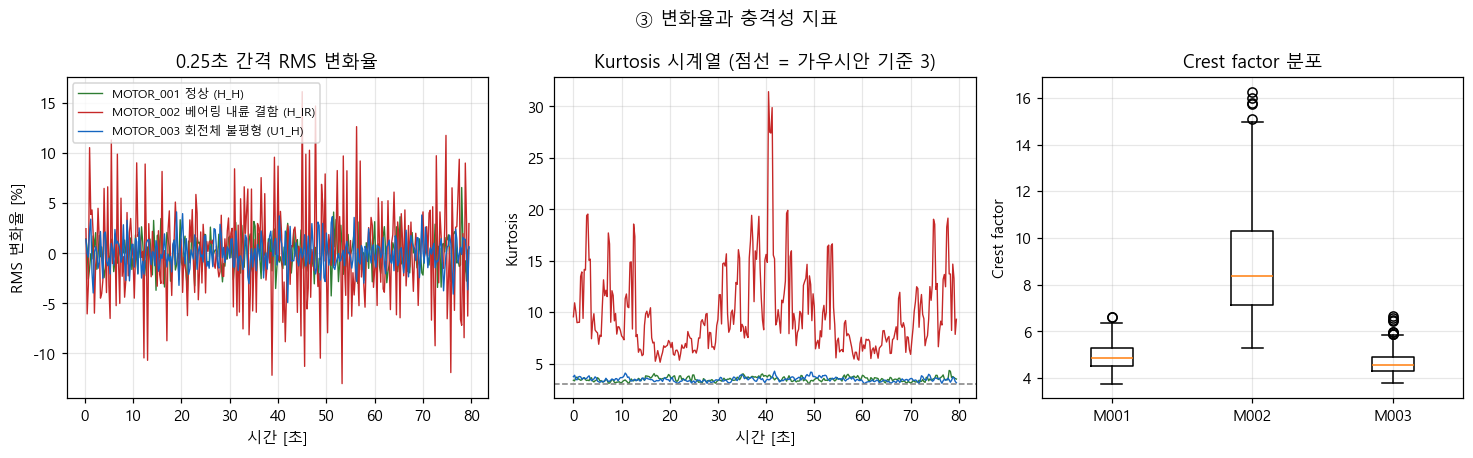

,변화율 표준편차(%),변화율 절대 최대(%),Kurtosis 평균,Kurtosis 최대,Crest 평균
설비,,,,,
MOTOR_001,1.649,6.571,3.490,4.331,4.928
MOTOR_002,4.689,16.147,9.905,31.441,9.011
MOTOR_003,1.533,4.921,3.456,4.257,4.658


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
rate_rows = []

for eq in signals:
    part = features[features.equipment == eq]
    change = part.rms.pct_change().dropna() * 100
    axes[0].plot(part.t.iloc[1:], change, color=COLORS[eq], linewidth=0.9, label=LABELS[eq])
    axes[1].plot(part.t, part["kurtosis"], color=COLORS[eq], linewidth=0.9, label=LABELS[eq])
    rate_rows.append({
        "설비": eq,
        "변화율 표준편차(%)": change.std(),
        "변화율 절대 최대(%)": change.abs().max(),
        "Kurtosis 평균": part["kurtosis"].mean(),
        "Kurtosis 최대": part["kurtosis"].max(),
        "Crest 평균": part.crest.mean(),
    })

axes[0].set(xlabel="시간 [초]", ylabel="RMS 변화율 [%]", title="0.25초 간격 RMS 변화율")
axes[1].axhline(3, color="gray", linestyle="--", linewidth=1)
axes[1].set(xlabel="시간 [초]", ylabel="Kurtosis", title="Kurtosis 시계열 (점선 = 가우시안 기준 3)")
axes[2].boxplot([features[features.equipment == eq].crest for eq in signals],
                tick_labels=[eq.replace("MOTOR_", "M") for eq in signals])
axes[2].set(ylabel="Crest factor", title="Crest factor 분포")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("③ 변화율과 충격성 지표", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_change_rate.png", bbox_inches="tight")
plt.show()

pd.DataFrame(rate_rows).set_index("설비").round(3)

**관찰** — `MOTOR_002`는 변화율 표준편차가 4.7%로 정상 설비(1.6%)의 약 3배이고, Kurtosis 평균이 9.9(최대 31.4)로 기준선 3을 계속 크게 웃돈다. `MOTOR_003`의 Kurtosis 평균 3.46과 Crest 평균 4.66은 `MOTOR_001`(3.49 / 4.93)과 사실상 겹친다.

**해석(가설)** — 충격성 지표는 베어링 결함에는 강하게 반응하지만 회전체 불평형에는 반응하지 않는다. 불평형은 충격이 아니라 회전 주파수에 동기된 매끄러운 힘이기 때문으로 보인다. 그렇다면 불평형은 시간 영역이 아니라 주파수 영역에서 찾아야 한다 → 7절.

## 7. 시각화 ④ 주파수 영역 — 시계열의 "계절성"

시계열에서 **계절성 = 일정 주기로 반복되는 성분**이다. 회전 기계에서 그 주기는 회전 주기이며,
1200 rpm = **20 Hz**가 기본(1x) 주파수다. 주기 성분은 FFT(여기서는 Welch PSD)로 보는 것이 직접적이다.
추가로 고주파 대역(2–6 kHz)의 **포락선 스펙트럼**을 계산한다. 반복 충격은 고주파를 얻어 타고 나타나므로,
포락선을 뜯어보면 충격이 몇 Hz로 반복되는지 읽을 수 있다.

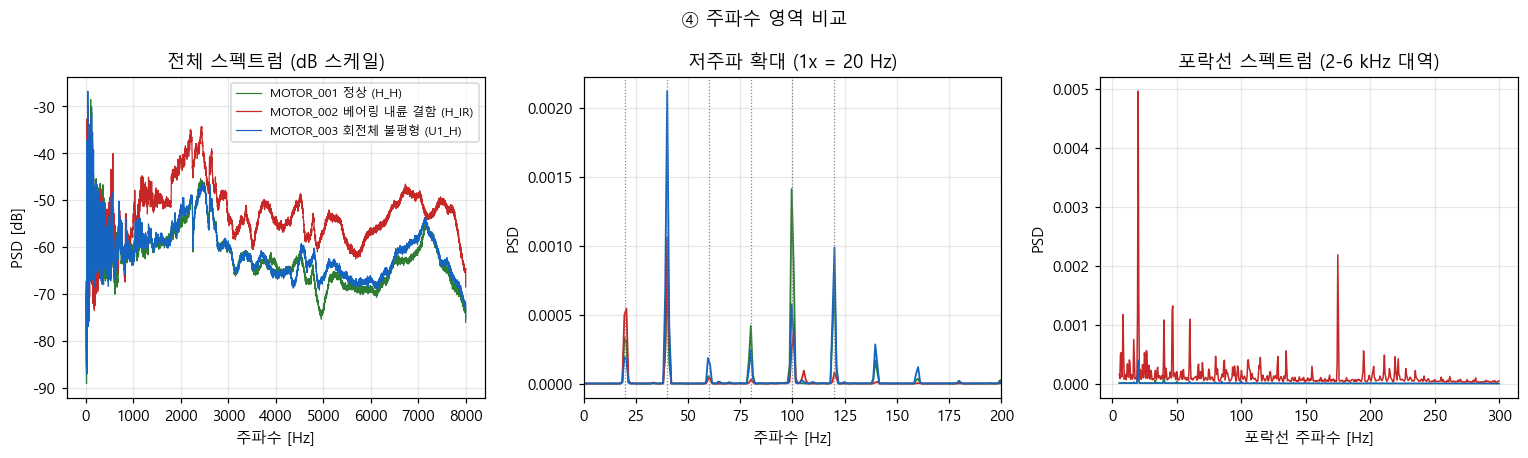

,0-100Hz(%),100-1k(%),1k-4k(%),4k-8k(%)
설비,,,,
MOTOR_001,22.6,18.4,49.7,9.3
MOTOR_002,2.5,2.4,78.7,16.4
MOTOR_003,24.2,18.5,45.5,11.8


,1x(20Hz),2x(40Hz),3x(60Hz),5x(100Hz),6x(120Hz)
설비,,,,,
MOTOR_001,3.33,7.49,0.53,14.11,7.49
MOTOR_002,5.43,10.59,0.39,3.72,0.81
MOTOR_003,1.92,21.21,1.85,5.75,9.86


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
band_rows, harmonic_rows = [], []
b, a = butter(4, [2000 / (FS / 2), 6000 / (FS / 2)], btype="band")

for eq, signal in signals.items():
    freq, psd = welch(signal, fs=FS, nperseg=16384)
    axes[0].plot(freq, 10 * np.log10(psd), color=COLORS[eq], linewidth=0.8, label=LABELS[eq])
    axes[1].plot(freq, psd, color=COLORS[eq], linewidth=1.2, label=LABELS[eq])

    envelope = np.abs(hilbert(filtfilt(b, a, signal)))
    env_freq, env_psd = welch(envelope - envelope.mean(), fs=FS, nperseg=32768)
    keep = (env_freq > 5) & (env_freq < 300)
    axes[2].plot(env_freq[keep], env_psd[keep], color=COLORS[eq], linewidth=1.0, label=LABELS[eq])

    total = psd.sum()
    band_rows.append({
        "설비": eq,
        "0-100Hz(%)": psd[freq < 100].sum() / total * 100,
        "100-1k(%)": psd[(freq >= 100) & (freq < 1000)].sum() / total * 100,
        "1k-4k(%)": psd[(freq >= 1000) & (freq < 4000)].sum() / total * 100,
        "4k-8k(%)": psd[freq >= 4000].sum() / total * 100,
    })
    harmonic_rows.append({"설비": eq, **{
        f"{int(h / ROT_HZ)}x({int(h)}Hz)": psd[(freq > h - 1.5) & (freq < h + 1.5)].max() * 1e4
        for h in (ROT_HZ, 2 * ROT_HZ, 3 * ROT_HZ, 5 * ROT_HZ, 6 * ROT_HZ)
    }})

axes[0].set(xlabel="주파수 [Hz]", ylabel="PSD [dB]", title="전체 스펙트럼 (dB 스케일)")
axes[1].set(xlim=(0, 200), xlabel="주파수 [Hz]", ylabel="PSD",
            title=f"저주파 확대 (1x = {ROT_HZ:.0f} Hz)")
for h in range(1, 7):
    axes[1].axvline(h * ROT_HZ, color="gray", linestyle=":", linewidth=0.8)
axes[2].set(xlabel="포락선 주파수 [Hz]", ylabel="PSD", title="포락선 스펙트럼 (2-6 kHz 대역)")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("④ 주파수 영역 비교", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_spectrum.png", bbox_inches="tight")
plt.show()

display(pd.DataFrame(band_rows).set_index("설비").round(1))
display(pd.DataFrame(harmonic_rows).set_index("설비").round(2))

In [9]:
# 포락선 스펙트럼에서 가장 강한 반복 성분 찾기 (회전 주파수의 정수배인지 확인)
peaks = []
for eq, signal in signals.items():
    envelope = np.abs(hilbert(filtfilt(b, a, signal)))
    env_freq, env_psd = welch(envelope - envelope.mean(), fs=FS, nperseg=32768)
    keep = (env_freq > 50) & (env_freq < 300)
    top = env_freq[keep][np.argmax(env_psd[keep])]
    peaks.append({"설비": eq, "50-300Hz 최대 성분[Hz]": top, "회전 주파수 배수": top / ROT_HZ})

pd.DataFrame(peaks).set_index("설비").round(2)

,50-300Hz 최대 성분[Hz],회전 주파수 배수
설비,,
MOTOR_001,50.29,2.51
MOTOR_002,174.80,8.74
MOTOR_003,100.10,5.00


**관찰**

- 대역 에너지: `MOTOR_002`는 에너지의 95%가 1 kHz 이상(1–4 kHz 78.7%, 4–8 kHz 16.4%)에 몰려 있다. 정상·불평형 설비는 0–100 Hz에 각각 22.6% / 24.2%가 남아 있다.
- 저주파 확대: `MOTOR_003`은 40 Hz(2x)에서 정상 설비의 약 2.8배, 60 Hz(3x)에서 약 3.5배 크다. 반면 20 Hz(1x)는 오히려 정상보다 작다.
- 포락선: `MOTOR_002`의 50–300 Hz 최대 성분은 174.8 Hz = 회전 주파수의 8.74배로, 정수배가 아니다. 정상·불평형 설비의 포락선에는 이만큼 두드러진 성분이 없다.

**해석(가설)**

- `MOTOR_002`의 고주파 집중과 비정수배 반복 성분은 베어링 내륜 결함의 전형적 패턴(고주파 공진이 결함 통과 주파수로 변조되는 현상)에 부합한다. 정수배가 아니라는 점은 회전체가 아니라 **베어링**이 원인임을 가리킨다.
- `MOTOR_003`은 회전 주파수의 배수 성분이 커졌으므로 원인이 회전체 쪽에 있다는 방향은 맞다. 다만 불평형의 교과서적 신호는 1x 증가인데 여기서는 2x·3x가 더 컸다. 센서 장착 방향, 커플링·정렬 상태 등 다른 요인이 섞였을 수 있어 **이 데이터만으로 단정하지 않는다.**

## 8. 시각화 ⑤ 두 지표로 본 분리도와 임계값

앞의 결과를 종합하면 RMS(크기)와 Kurtosis(충격성)는 서로 다른 고장을 잡는다.
두 축을 함께 놓고 세 설비가 실제로 분리되는지 확인한다.

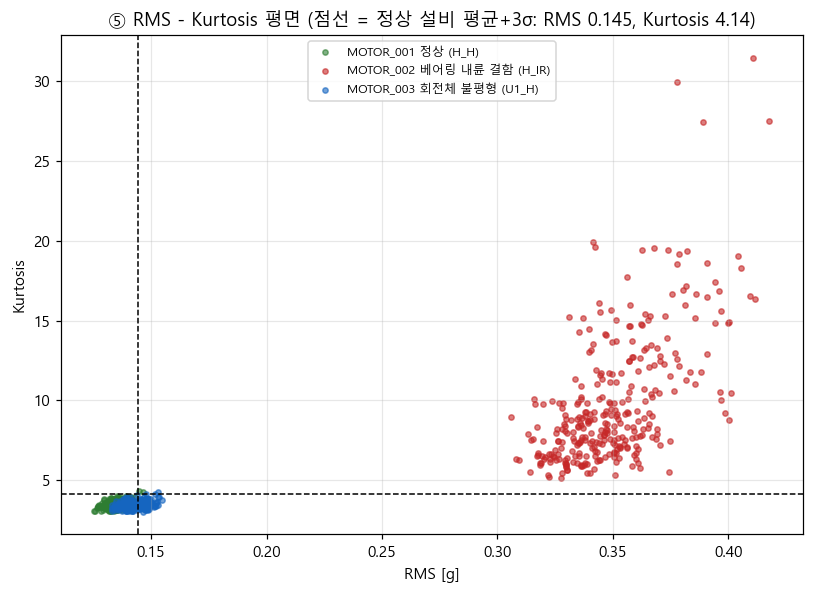

,RMS_초과,Kurtosis_초과,둘_중_하나_초과
equipment,,,
MOTOR_001,0.6,0.6,0.6
MOTOR_002,100.0,100.0,100.0
MOTOR_003,33.2,0.9,33.2


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for eq in signals:
    part = features[features.equipment == eq]
    ax.scatter(part.rms, part["kurtosis"], s=12, alpha=0.6, color=COLORS[eq], label=LABELS[eq])

normal = features[features.equipment == "MOTOR_001"]
rms_th = normal.rms.mean() + 3 * normal.rms.std()
kurt_th = normal["kurtosis"].mean() + 3 * normal["kurtosis"].std()
ax.axvline(rms_th, color="black", linestyle="--", linewidth=1)
ax.axhline(kurt_th, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="RMS [g]", ylabel="Kurtosis",
       title=f"⑤ RMS - Kurtosis 평면 (점선 = 정상 설비 평균+3σ: RMS {rms_th:.3f}, Kurtosis {kurt_th:.2f})")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_rms_kurtosis.png", bbox_inches="tight")
plt.show()

alarm = features.assign(
    RMS_초과=features.rms > rms_th,
    Kurtosis_초과=features["kurtosis"] > kurt_th,
)
alarm["둘_중_하나_초과"] = alarm.RMS_초과 | alarm.Kurtosis_초과
(alarm.groupby("equipment")[["RMS_초과", "Kurtosis_초과", "둘_중_하나_초과"]].mean() * 100).round(1)

**관찰** — 정상 설비의 평균 + 3σ를 임계값으로 잡으면 `MOTOR_002`는 319개 구간 전부(100%)가 두 지표 모두 초과한다. `MOTOR_003`은 Kurtosis 초과가 0.9%에 그치지만 RMS 초과는 33.2%로, 임계선 위아래를 오간다. 산점도에서도 `MOTOR_003`(파랑)은 `MOTOR_001`(초록) 무리와 겹친 채 RMS 축으로만 조금 밀려 있다.

**해석(가설)** — 시간 영역 지표 기반 임계값은 베어링 결함에는 확실히 듣지만, 불평형에는 "3분의 1만 걸리는" 불안정한 판정을 준다. 이 상태로 알람을 걸면 불평형은 깜빡이는 경보(오탐·미탐이 섞인 상태)가 된다. 불평형까지 안정적으로 잡으려면 회전 주파수 배수 대역의 에너지(예: 40 Hz 성분) 같은 **주파수 기반 지표를 알람 규칙에 추가**해야 한다.

## 8-1. 현재 운영 중인 알람 규칙에 대입하면

위 임계값은 이 노트북이 정상 설비에서 유도한 값이다. 실제 운영 코드
(`ai-api/app/services/feature_service.py`)는 데이터셋 전체로 보정한 자체 임계값을 쓰고,
네 지표 중 **가장 높은 점수**로 `normal` / `warning` / `danger`를 판정한다.
운영과 같은 조건(2초 window, 1초 stride = 설비당 79개)에서 그 규칙을 그대로 적용해 본다.

In [11]:
# ai-api/app/services/feature_service.py 의 값 (데이터셋 전체로 보정된 운영 임계값)
BASE_SPAN = {
    "rms": (0.2366, 0.0400),
    "p2p": (2.1648, 3.6230),
    "crest": (9.2796, 1.4261),
    "kurtosis": (5.7771, 5.6251),
}
PROD_FRAME, PROD_HOP = 32000, 16000  # 2초 window, 1초 stride


def production_windows(signal):
    n = (len(signal) - PROD_FRAME) // PROD_HOP + 1
    frames = np.stack([signal[i * PROD_HOP:i * PROD_HOP + PROD_FRAME] for i in range(n)])
    rms = np.sqrt((frames ** 2).mean(axis=1))
    return pd.DataFrame({
        "rms": rms,
        "p2p": frames.max(axis=1) - frames.min(axis=1),
        "crest": np.abs(frames).max(axis=1) / rms,
        "kurtosis": kurtosis(frames, axis=1, fisher=False),
    })


def alarm_level(score):
    return "danger" if score >= 0.8 else "warning" if score >= 0.5 else "normal"


prod_rows = []
for eq, signal in signals.items():
    win = production_windows(signal)
    scores = pd.concat(
        [((win[col] - base) / span).clip(0, 1) for col, (base, span) in BASE_SPAN.items()],
        axis=1,
    ).max(axis=1)
    levels = scores.map(alarm_level).value_counts()
    prod_rows.append({
        "설비": eq,
        "window 수": len(win),
        "이상점수 평균": scores.mean(),
        "normal": levels.get("normal", 0),
        "warning": levels.get("warning", 0),
        "danger": levels.get("danger", 0),
    })

pd.DataFrame(prod_rows).set_index("설비").round(3)

,window 수,이상점수 평균,normal,warning,danger
설비,,,,,
MOTOR_001,79,0.0,79,0,0
MOTOR_002,79,1.0,0,0,79
MOTOR_003,79,0.0,79,0,0


**관찰** — 운영 임계값을 그대로 적용하면 `MOTOR_002`는 79개 window 전부가 `danger`, `MOTOR_001`과 `MOTOR_003`은 전부 `normal`이고 이상 점수는 0이다.

**해석(가설)** — 불평형 설비가 "정상"으로 판정되는 것은 임계값이 잘못 잡혔기 때문이 아니라, 판정에 쓰는 네 지표(RMS·P2P·Crest·Kurtosis)가 **모두 시간 영역 지표**여서 불평형에 원래 반응하지 않기 때문이다. 임계값을 낮추면 정상 설비까지 함께 걸리므로(5절에서 본 두 설비의 RMS 분포가 겹친다) 문제를 해결하지 못한다. 지표 자체를 추가하는 것이 맞는 방향이다.

## 9. 정리

- 질문 1: **부분적으로만 가능.** RMS는 베어링 결함을 분명히 구분하지만 불평형은 정상과 거의 같다.
- 질문 2: **있다.** Kurtosis·Crest·변화율이 베어링 결함을 추가로 드러낸다. 단, 불평형에는 반응하지 않는다.
- 질문 3: 80초 구간에 **장기 트렌드는 없고**, 주기 성분은 회전 주파수(20 Hz)의 배수로 나타나며, 나머지는 설비마다 크기가 다른 노이즈다.
- 질문 4: 정상 대비 3σ 임계값은 베어링 결함을 100% 잡지만, 불평형은 RMS 기준 33%만 걸려 판정이 불안정하다. 주파수 지표 병행이 필요하다.

상세한 서술과 한계점은 [REPORT.md](REPORT.md) 참고.